In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import librosa
import os

Вычисление ошибок

In [3]:
df_preds = pd.read_csv("/home/ext-ivanova-mk@ad.speechpro.com/test_dir/vox-profile-release/src/example/voicebio_predictions.csv")

In [4]:
df_preds.head()

,id,year,true_age,pred_age,file
0,id00021,2020,33,46.90,/mnt/storage/work_dir/databases/voice_biometri...
1,id00021,2019,32,38.70,/mnt/storage/work_dir/databases/voice_biometri...
2,id00021,2022,35,42.72,/mnt/storage/work_dir/databases/voice_biometri...
3,id00021,2021,34,53.14,/mnt/storage/work_dir/databases/voice_biometri...
4,id00021,2023,36,41.68,/mnt/storage/work_dir/databases/voice_biometri...


In [6]:
df_preds['error'] = df_preds['pred_age'] - df_preds['true_age']  
df_preds['abs_error'] = abs(df_preds['error'])                  
df_preds['squared_error'] = df_preds['error'] ** 2              

# Метрики
MAE = abs(df_preds['pred_age'] - df_preds['true_age']).mean()
MSE = ((df_preds['pred_age'] - df_preds['true_age'])**2).mean()
RMSE = np.sqrt(MSE)
STD_ERROR = (df_preds['pred_age'] - df_preds['true_age']).std()

# Дополнительные метрики в пределах
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100

print("Метрики оценки")

print(f"\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print(f"\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки

Основные метрики:
MAE  (Mean Absolute Error):     8.713 лет
RMSE (Root Mean Squared Error): 11.310 лет
Std of Error (разброс ошибок):  11.210 лет

Процент ошибок в пределах:
  ≤ 1 год:   7.8%
  ≤ 3 года:  23.4%
  ≤ 5 лет:   39.1%
  ≤ 10 лет:   65.5%

Статистика абсолютных ошибок:
  Мин ошибка:  0.010 лет
  Медиана:     7.040 лет
  Макс ошибка: 45.030 лет


Macro MAE

In [ ]:
# Возрастные группы
bins = [0, 20, 30, 40, 50, 60, 70]  # Границы групп
labels = ['0-20', '20-30', '30-40', '40-50', '50-60', '60-70']

df_preds['age_group'] = pd.cut(df_preds['true_age'], bins=bins, labels=labels, right=False)

# MAE для каждой группы
mae_by_group = df_preds.groupby('age_group')['abs_error'].mean()

# Макро MAE
macro_mae = mae_by_group.mean()

# Взвешенная MAE
weighted_mae = (df_preds.groupby('age_group')['abs_error']
                         .agg(['mean', 'count'])
                         .assign(weighted=lambda x: x['mean'] * x['count'] / x['count'].sum())
                         ['weighted'].sum())

print(f"MAE по возрастным группам:\n")
print(mae_by_group)
print(f"\nMacro MAE: {macro_mae:.3f} лет")
print(f"MAE: {weighted_mae:.3f} лет")

MAE по возрастным группам:

age_group
0-20      8.491667
20-30     8.248638
30-40     8.809315
40-50    10.436795
50-60     8.481765
60-70     6.070000
Name: abs_error, dtype: float64

Macro MAE: 8.423 лет
MAE: 8.713 лет


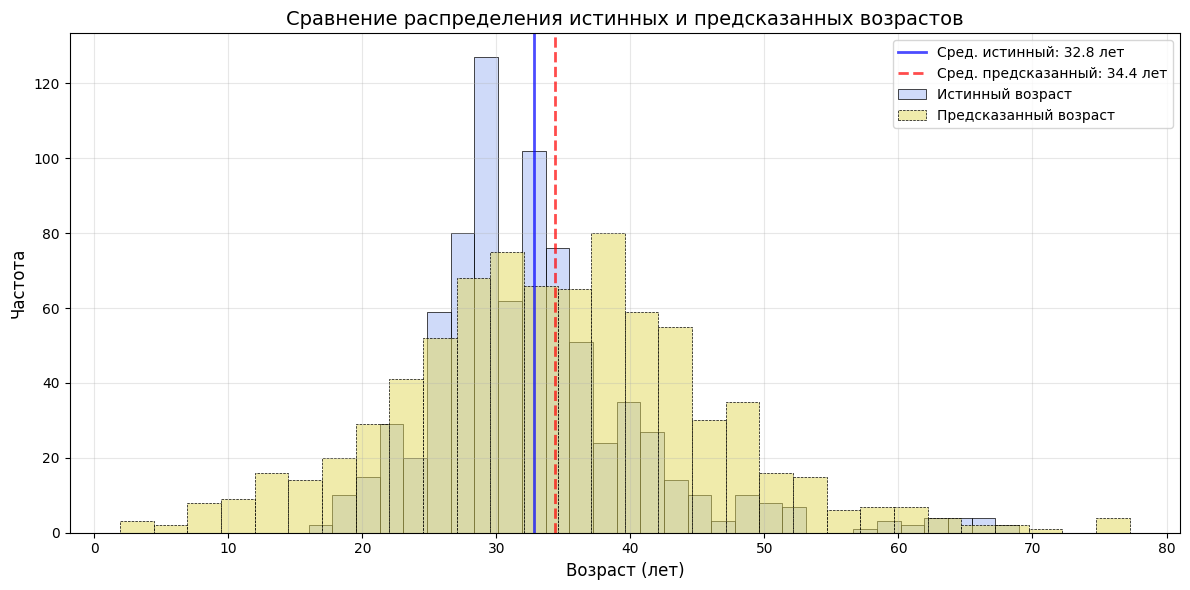

In [7]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='true_age', bins=30, 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='pred_age', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['pred_age'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["pred_age"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()